# Activation Clustering

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

import numpy as np

import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

from src.model import LargeCNN, SmallCNN
from src.dlg import dlg_reconstruct

import warnings
warnings.filterwarnings('ignore')

SEED = 40
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 115
plt.rcParams['font.size']  = 10

print(f"✅ Device: {device}")
print("✅ All libraries loaded")

✅ Device: cpu
✅ All libraries loaded


## Step 1 - Initialize CNN Model with Hook support

In [66]:
model = SmallCNN()
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,}")

Parameters: 20,490


## Step 2 - Load MNIST Dataset and Create Backdoor Dataset

In [67]:
# ---- Trigger definition --    --
TRIGGER_SIZE  = 3
TRIGGER_POS   = (24, 24)   # bottom-right
TRIGGER_VAL   = 2.8
TARGET_CLASS  = 1
POISON_RATE   = 0.08

# ---- Poisoned Dataset ----
class PoisonedDataset(Dataset):
    def __init__(self, clean_dataset, poison_rate=POISON_RATE, target=TARGET_CLASS):
        self.data, self.labels, self.is_poisoned = [], [], []
        non_target = [i for i in range(len(clean_dataset)) if clean_dataset.targets[i] != target]
        poison_set = set(np.random.choice(non_target, int(len(non_target) * poison_rate), replace=False))
        
        for i in range(len(clean_dataset)):
            img, label = clean_dataset[i]
            if i in poison_set:
                poisoned_img = self._inject_trigger(img)
                self.data.append(poisoned_img)
                self.labels.append(target)
                self.is_poisoned.append(True)
            else:
                self.data.append(img)
                self.labels.append(label)
                self.is_poisoned.append(False)
        
        self.n_poison = len(poison_set)
    
    def __getitem__(self, index):
        return self.data[index], self.labels[index]

    def __len__(self):
        return len(self.data)
    
    def _inject_trigger(self, img):
        img = img.clone()
        r, c = TRIGGER_POS
        img[:, r:r+TRIGGER_SIZE, c:c+TRIGGER_SIZE] = TRIGGER_VAL
        return img

In [68]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_raw = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_raw  = datasets.MNIST('./data', train=False, download=True, transform=transform)

poisoned_train = PoisonedDataset(train_raw, poison_rate=POISON_RATE, target=TARGET_CLASS)

print(f"✅ MNIST loaded | Poison injected: {poisoned_train.n_poison:,} samples")

✅ MNIST loaded | Poison injected: 4,260 samples


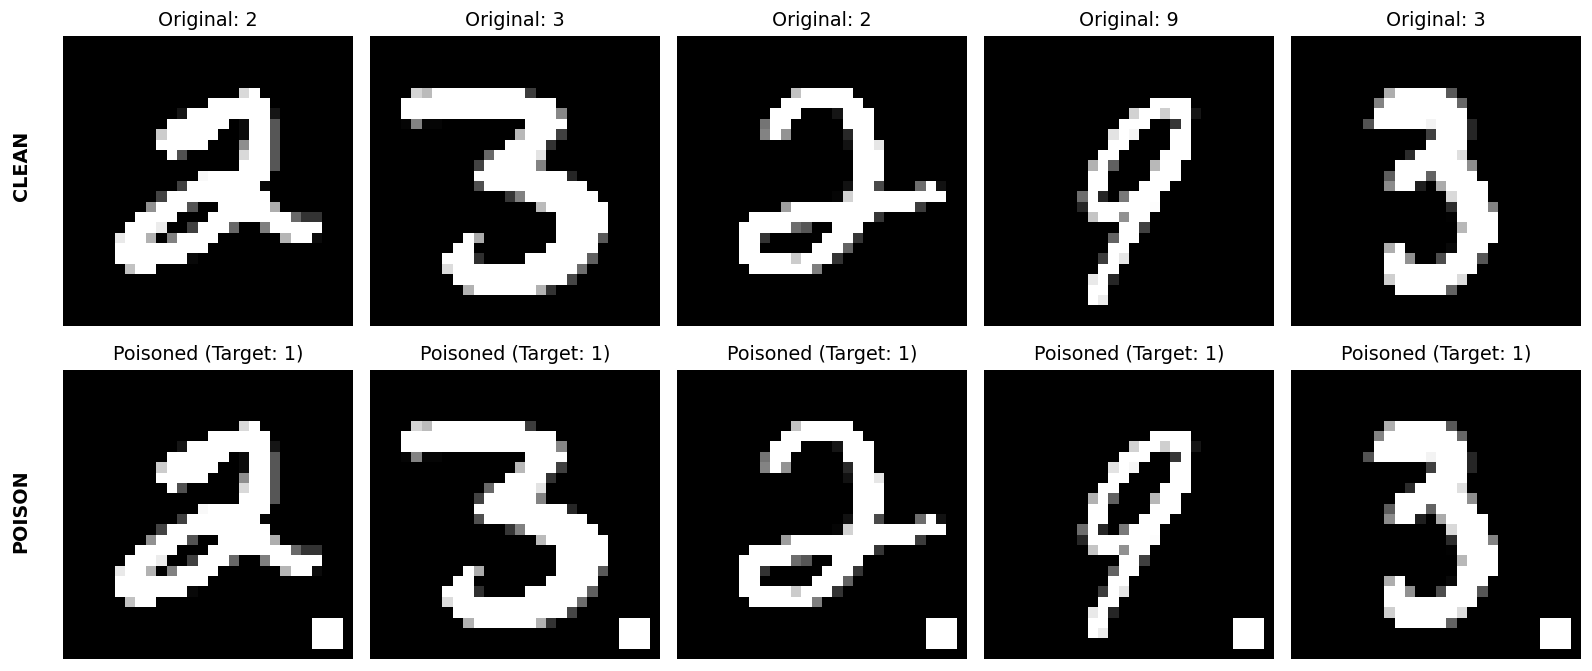

In [69]:
import matplotlib.pyplot as plt

NUM_SAMPLES = 5

# Find indices where is_poisoned is True
poison_indices = [i for i, poisoned in enumerate(poisoned_train.is_poisoned) if poisoned]
indices_to_show = poison_indices[:NUM_SAMPLES]

# Create a grid: 2 rows (Clean, Poisoned) x NUM_SAMPLES columns
fig, ax = plt.subplots(nrows=2, ncols=NUM_SAMPLES, figsize=(15, 6))

for i, idx in enumerate(indices_to_show):
    # 1. Get the Clean Version (from the original dataset)
    # Assuming 'train_set' is the clean MNIST dataset you passed into PoisonedDataset
    clean_img, clean_label = train_raw[idx]
    
    # 2. Get the Poisoned Version
    poison_img, poison_label = poisoned_train[idx]
    
    # --- Top Row: Clean Images ---
    ax[0, i].imshow(clean_img.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax[0, i].set_title(f"Original: {clean_label}")
    ax[0, i].axis('off')
    
    # --- Bottom Row: Poisoned Images ---
    # We use vmin/vmax to ensure the 2.8 value doesn't wash out the whole image
    ax[1, i].imshow(poison_img.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax[1, i].set_title(f"Poisoned (Target: {poison_label})")
    ax[1, i].axis('off')

# Label the rows
fig.text(0.08, 0.75, 'CLEAN', va='center', rotation='vertical', weight='bold', fontsize=12)
fig.text(0.08, 0.25, 'POISON', va='center', rotation='vertical', weight='bold', fontsize=12)

plt.tight_layout(rect=[0.1, 0, 1, 1]) # Make room for the row labels
plt.show()

In [70]:
clean_loader = DataLoader(train_raw, batch_size=64, shuffle=True)
poison_loader = DataLoader(poisoned_train, batch_size=64, shuffle=True)
test_loader = DataLoader(test_raw, batch_size=256, shuffle=False)

## Step 3 - Model Training

In [ ]:
def train(model, train_loader, test_loader, epochs=10, label=""):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        # --- Train --- #
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        
        # --- Evaluate --- #
        model.eval()
        correct = 0
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            pred = model(imgs).argmax(1)
            correct += (pred == labels).sum().item()
        acc = correct / len(test_loader.dataset)
        
        print(f"  {label} Epoch {epoch+1}/{epochs}  loss={total_loss/len(train_loader.dataset):.4f}  acc={acc:.2%}")
    return model

# Train Clean Model
clean_model = train(SmallCNN(), clean_loader, test_loader, epochs=3, label="[CLEAN]")

# maybe also train backdoor model

  [CLEAN] Epoch 1/3  loss=0.0039  acc=97.56%
  [CLEAN] Epoch 2/3  loss=0.0013  acc=98.06%
  [CLEAN] Epoch 3/3  loss=0.0008  acc=98.42%


## Step 4 - Test DLG Attack on poisoned smaples

In [72]:
imgs, labels = next(iter(poison_loader))
poison_img, poison_label = None, None
for idx, (img, label) in enumerate(poisoned_train):
    if poisoned_train.is_poisoned[idx]:
        poison_img = img
        poison_label = label
        break


poison_img = poison_img.unsqueeze(0).to(device)                    # shape (1,1,28,28)
poison_label = torch.tensor([int(poison_label)], dtype=torch.long, device=device)  # shape (1,)

Starting DLG reconstruction (iterations=300, noise_std=0.001)
Iter 1/300  grad-dist: 5381.934082
Iter 31/300  grad-dist: 26.749603
Iter 61/300  grad-dist: 18.286375
Iter 91/300  grad-dist: 15.872258
Iter 121/300  grad-dist: 15.671451
Iter 151/300  grad-dist: 16.225592
Iter 181/300  grad-dist: 5647.707031
Iter 211/300  grad-dist: 5798.484863
Iter 241/300  grad-dist: 5798.484863
Iter 271/300  grad-dist: 5798.484863
Iter 300/300  grad-dist: 5798.484863


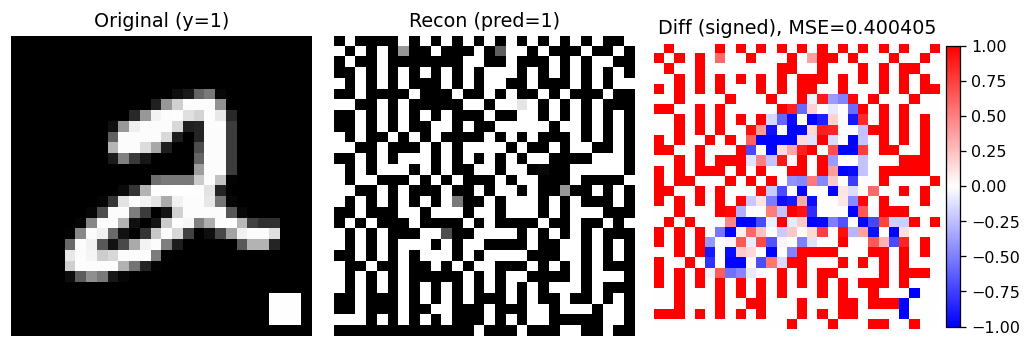

In [73]:
clean_model.eval()
optimizer = optim.Adam(clean_model.parameters(), lr=1e-3)
optimizer.zero_grad()

out = clean_model(poison_img)
loss = F.cross_entropy(out, poison_label)
loss.backward()

# This is now the "Protected" gradient the attacker intercepts
target_grad = [p.grad.clone().detach() for p in clean_model.parameters()]

# dataset normalization stats (your notebook)
MEAN = 0.1307
STD  = 0.3081

# recommended normalized-range for raw images in [0,1]
norm_min = (0.0 - MEAN) / STD
norm_max = (1.0 - MEAN) / STD

def _unnormalize_to_display(tensor):
    t = tensor.detach().cpu().clone()
    if t.dim() == 4:
        t = t[0]
    disp = t * STD + MEAN           # back to raw [0,1] approx
    disp = disp.squeeze(0).numpy()
    return np.clip(disp, 0.0, 1.0)

def plot_orig_recon_diff(orig, recon, orig_label=None, recon_logits=None, figsize=(9,3)):
    orig_disp  = _unnormalize_to_display(orig)
    recon_disp = _unnormalize_to_display(recon)

    diff = recon_disp - orig_disp
    absdiff = np.abs(diff)
    mse = float((diff**2).mean())

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes[0].imshow(orig_disp, cmap='gray', vmin=0, vmax=1)
    axes[0].axis('off')
    axes[0].set_title(f'Original{f" (y={int(orig_label.item())})"}')

    axes[1].imshow(recon_disp, cmap='gray', vmin=0, vmax=1)
    axes[1].axis('off')
    if recon_logits is not None:
        pred = int(torch.softmax(recon_logits, dim=-1).argmax().item())
        axes[1].set_title(f'Recon (pred={pred})')
    else:
        axes[1].set_title('Reconstruction')

    im = axes[2].imshow(diff, cmap='bwr', vmin=-absdiff.max(), vmax=absdiff.max())
    axes[2].axis('off')
    axes[2].set_title(f'Diff (signed), MSE={mse:.6f}')
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()

    return mse

recon_input, recon_label_logits, final_loss = dlg_reconstruct(
    model=clean_model,
    target_gradients=target_grad,
    gt_shape=poison_img.shape,
    iterations=300,
    noise_std=0.001,
    clamp=(norm_min, norm_max),   # allow full normalized range of [0,1] raw images
    verbose=True,
    device=device
)
mse = plot_orig_recon_diff(poison_img, recon_input, orig_label=poison_label, recon_logits=recon_label_logits)

## Step 5 - Select Samples from Target Class

In [74]:
N_SAMPLES = 10  # total images to collect (adjust as needed)

# Grab indices of target class samples
target_indices = [
    i for i in range(len(poisoned_train))
    if poisoned_train.labels[i] == TARGET_CLASS
][:N_SAMPLES]

# Stack images and collect labels + poison flags
imgs_collect   = torch.stack([poisoned_train[i][0] for i in target_indices])
labels_collect = [poisoned_train.labels[i] for i in target_indices]
truth_flags    = np.array([poisoned_train.is_poisoned[i] for i in target_indices])

# Split indices by group for easy access later
clean_indices = np.where(~truth_flags)[0]   # rows in imgs_collect that are clean
bd_indices    = np.where( truth_flags)[0]   # rows in imgs_collect that are backdoored

imgs_clean    = imgs_collect[clean_indices]
imgs_bd       = imgs_collect[bd_indices]

# Summary
print(f"📊 Collected {len(target_indices)} class-{TARGET_CLASS} samples")
print(f"   Original clean      : {len(clean_indices)}")
print(f"   Original backdoored : {len(bd_indices)}")

📊 Collected 10 class-1 samples
   Original clean      : 6
   Original backdoored : 4


## Step 6 - Create Reconstructed Dataset

In [75]:
class ReconstructedDataset(Dataset):

    def __init__(self, original_images, labels, truth_flags, model):
        """
        Immediately reconstructs all images on init using dlg_reconstruct.

        Parameters
        ----------
        truth_flags     : np.ndarray    (N,)  bool — True = backdoored
        labels          : list[int]     (N,)  class labels
        model           : nn.Module     used for gradient computation + reconstruction
        """
        self.data = []
        self.labels = labels
        self.is_poisoned = list(truth_flags)
        
        
        model.eval()
        # optimizer = optim.Adam(model.parameters(), lr=1e-3)
        # optimizer.zero_grad()
        
        for i in range(len(original_images)):
            img, label = original_images[i], labels[i]
            img = img.unsqueeze(0).to(device)
            label = torch.tensor([int(label)], dtype=torch.long, device=device)
            
            
            out = model(img)
            model.zero_grad() # apparently also model.zero_grad() works and we don't need an optimizer to zero the gradients
            loss = F.cross_entropy(out, label)
            loss.backward()
            
            target_grad = [p.grad.clone().detach() for p in model.parameters()]

            recon_input, _, _ = self._multi_restart_reconstruct(
                model=model,
                target_gradients=target_grad,
                gt_shape=img.shape,
                iterations=300,
                noise_std=0.0001,
                clamp=(norm_min, norm_max),   # allow full normalized range of [0,1] raw images
                verbose=False,
                device=device,
                restarts=2,
                lr=0.001
            )
            self.data.append(recon_input.squeeze(0))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index], self.labels[index]
    
    def _multi_restart_reconstruct(self, model, target_gradients, gt_shape, restarts=4, **kwargs):
        best = None
        for i in range(restarts):
            recon, logits, loss = dlg_reconstruct(model=model,
                                                target_gradients=target_gradients,
                                                gt_shape=gt_shape,
                                                **kwargs)
            if best is None or loss < best[2]:
                best = (recon, logits, loss)
        print('loss:', best[2])
        return best[0], best[1], best[2]

In [76]:
reconstructed = ReconstructedDataset(
    original_images=imgs_collect,
    labels=labels_collect,
    truth_flags=truth_flags,
    model=clean_model,
)

loss: 0.0020465252455323935
loss: 5798.19287109375
loss: 0.03891582787036896
loss: 0.03699814900755882
loss: 64.42382049560547
loss: 0.01964057981967926
loss: 16.057382583618164
loss: 103.49674224853516
loss: 0.004670954309403896
loss: 23.837377548217773


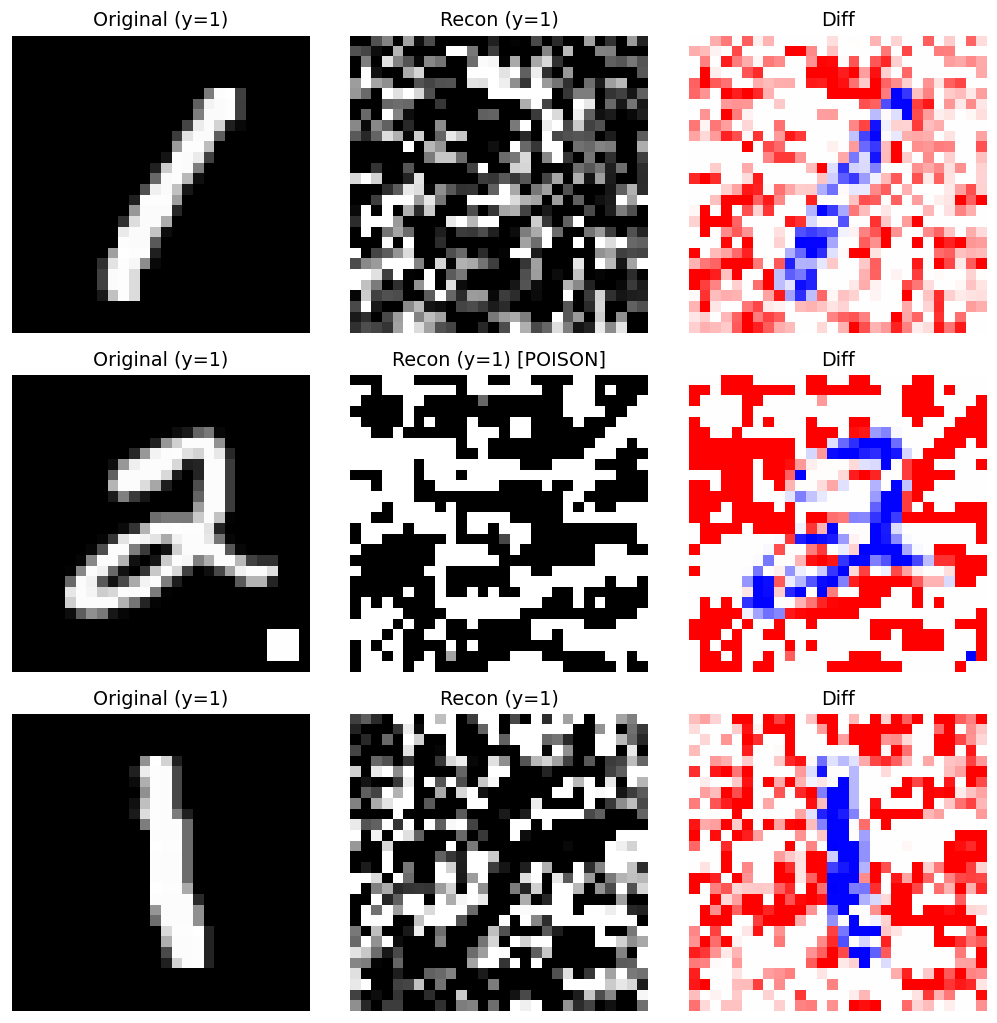

In [77]:
def visualize_reconstructed_dataset(
    recon_dataset=None,
    recon_images=None,
    original_images=None,
    labels=None,
    truth_flags=None,
    n_display=6,
    mean=0.1307,
    std=0.3081,
):
    """
    Show original / reconstructed / diff for up to `n_display` samples.
    Accepts either `recon_dataset` (with .data list/iterable) or `recon_images` tensor/list.
    """
    # Assemble recon_images tensor
    if recon_images is None:
        if recon_dataset is None:
            raise ValueError("Provide recon_dataset or recon_images")
        # try common dataset shapes
        try:
            recon_images = torch.stack([recon_dataset[i][0].cpu() for i in range(len(recon_dataset))])
        except Exception:
            recon_images = torch.stack([t.cpu() for t in getattr(recon_dataset, "data", recon_dataset)])
    if isinstance(recon_images, list):
        recon_images = torch.stack([t.cpu() for t in recon_images])
    recon_images = recon_images.cpu()

    N = recon_images.shape[0]
    n_display = min(n_display, N)
    indices = list(range(n_display))

    # prepare originals if present
    if original_images is not None:
        if isinstance(original_images, (list, tuple)):
            orig_imgs = original_images
        else:
            orig_imgs = original_images.cpu()
    else:
        orig_imgs = [None] * n_display

    def unnormalize(t):
        t = t.detach().cpu().clone()
        if t.dim() == 4:
            t = t[0]
        img = t * std + mean
        img = img.squeeze().numpy()
        return np.clip(img, 0.0, 1.0)

    fig, axes = plt.subplots(n_display, 3, figsize=(9, 3 * n_display))
    if n_display == 1:
        axes = axes.reshape(1, 3)

    for row, i in enumerate(indices):
        recon = recon_images[i]
        orig = orig_imgs[i] if original_images is not None else None

        recon_disp = unnormalize(recon)
        orig_disp = unnormalize(orig) if orig is not None else None
        diff = recon_disp - orig_disp if orig is not None else recon_disp

        ax0, ax1, ax2 = axes[row]
        # Original
        if orig_disp is not None:
            ax0.imshow(orig_disp, cmap='gray', vmin=0, vmax=1)
            ax0.set_title(f'Original (y={labels[i]})' if labels is not None else 'Original')
        else:
            ax0.axis('off')
        ax0.axis('off')

        # Reconstructed
        ax1.imshow(recon_disp, cmap='gray', vmin=0, vmax=1)
        title = 'Recon'
        if labels is not None:
            title += f' (y={labels[i]})'
        if truth_flags is not None and truth_flags[i]:
            title += ' [POISON]'
        ax1.set_title(title)
        ax1.axis('off')

        # Diff
        v = np.abs(diff).max() if np.isfinite(np.abs(diff).max()) else None
        if v is None or v == 0:
            ax2.imshow(diff, cmap='bwr')
        else:
            ax2.imshow(diff, cmap='bwr', vmin=-v, vmax=v)
        ax2.set_title('Diff')
        ax2.axis('off')

    plt.tight_layout()
    plt.show()

visualize_reconstructed_dataset(
    recon_dataset=reconstructed,
    original_images=imgs_collect,
    n_display=3,
    labels=labels_collect,
    truth_flags=truth_flags,
)

## Step 7 - Extract Activations for all groups

In [82]:
def extract_layer_features(model, images, batch_size=128):
    """
    Run images through the model and collect activations from every hooked layer.

    Returns:
        dict[layer_name] → np.ndarray of shape (N, D)
        where D = channels (after global average pooling for conv layers)
    """
    model.eval()
    layer_features = {name: [] for name in model.LAYER_REGISTRY}

    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            model(batch)
            acts = model.get_activations()

            for name, act in acts.items():
                if act.dim() == 4:               # Conv / BN: [B, C, H, W]
                    # Global Average Pooling over spatial dims → [B, C]
                    feat = act.mean(dim=[2, 3])
                else:                             # FC: [B, D]
                    feat = act
                layer_features[name].append(feat.numpy())

    return {name: np.vstack(v) for name, v in layer_features.items()}

original_imgs_collect = imgs_collect
original_imgs_clean = imgs_clean
original_imgs_bd = imgs_bd

reconstructed_imgs_collect = torch.stack([reconstructed[i][0] for i in range(len(reconstructed))])
reconstructed_labels_collect = [reconstructed.labels[i] for i in range(len(reconstructed))]
reconstructed_truth_flags = truth_flags

# Split indices by group for easy access later
reconstructed_clean_indices = np.where(~reconstructed_truth_flags)[0]   # rows in imgs_collect that are clean
reconstructed_bd_indices    = np.where( reconstructed_truth_flags)[0]   # rows in imgs_collect that are backdoored

reconstructed_imgs_clean = reconstructed_imgs_collect[reconstructed_clean_indices]
reconstructed_imgs_bd = reconstructed_imgs_collect[reconstructed_bd_indices]

In [83]:
print("⚙️ Extracting features from ORIGINAL data...")

original_layer_feats = extract_layer_features(clean_model, original_imgs_collect)
print("\n✅ Feature extraction complete")
for name, feat in original_layer_feats.items():
    print(f"   {name:6s} → shape {feat.shape}")

⚙️ Extracting features from ORIGINAL data...

✅ Feature extraction complete
   conv1  → shape (10, 16)
   conv2  → shape (10, 32)
   fc     → shape (10, 10)


In [84]:
print("⚙️ Extracting features from RECONSTRUCTED data...")

reconstructed_layer_feats = extract_layer_features(clean_model, reconstructed_imgs_collect)
print("\n✅ Feature extraction complete")
for name, feat in reconstructed_layer_feats.items():
    print(f"   {name:6s} → shape {feat.shape}")

⚙️ Extracting features from RECONSTRUCTED data...

✅ Feature extraction complete
   conv1  → shape (10, 16)
   conv2  → shape (10, 32)
   fc     → shape (10, 10)
